In [48]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv



**California Housing Price Prediction Notebook**
**1. Import Libraries**


In [49]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**2. Load Dataset**

In [50]:
path = "/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv"

housing = pd.read_csv(path)

housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**3. Dataset Overview:**
   shape and data type

In [51]:
print("Shape:", housing.shape)
housing.info()

Shape: (20640, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Statistical Summary

In [52]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Missing Values

In [53]:
housing.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

**4. Exploratory Data Analysis (EDA)**

Target Distribution

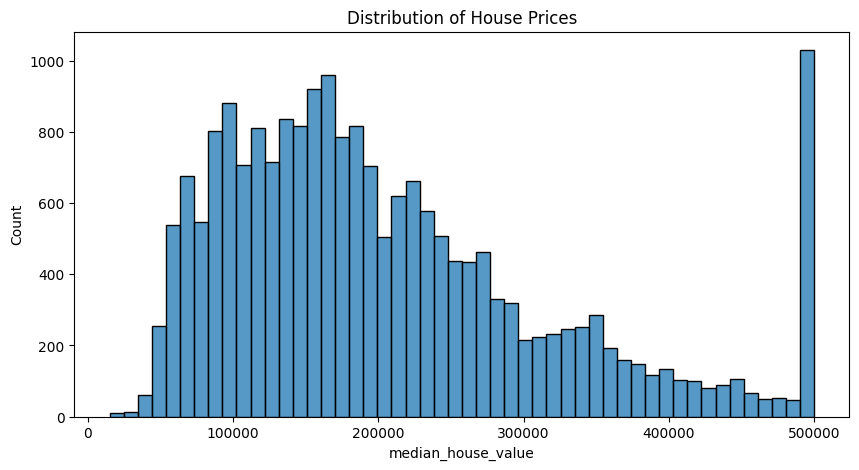

In [54]:
plt.figure(figsize=(10,5))
sns.histplot(housing["median_house_value"], bins=50)
plt.title("Distribution of House Prices")
plt.show()

Correlation Heatmap

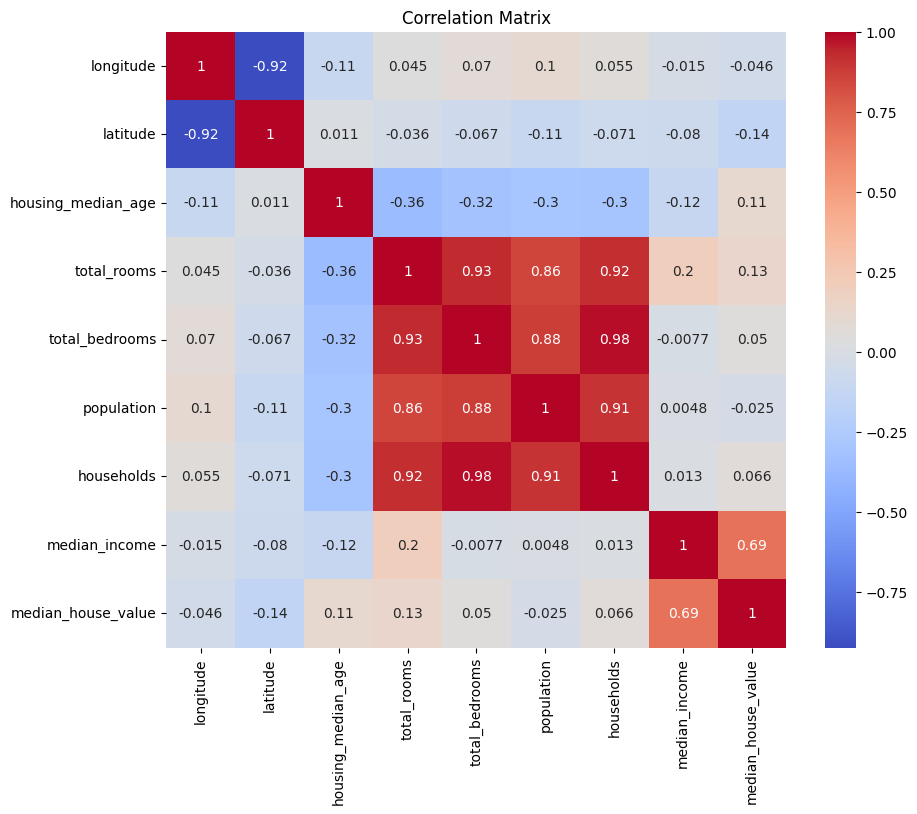

In [55]:
plt.figure(figsize=(10,8))

corr = housing.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

Ocean Proximity Distribution

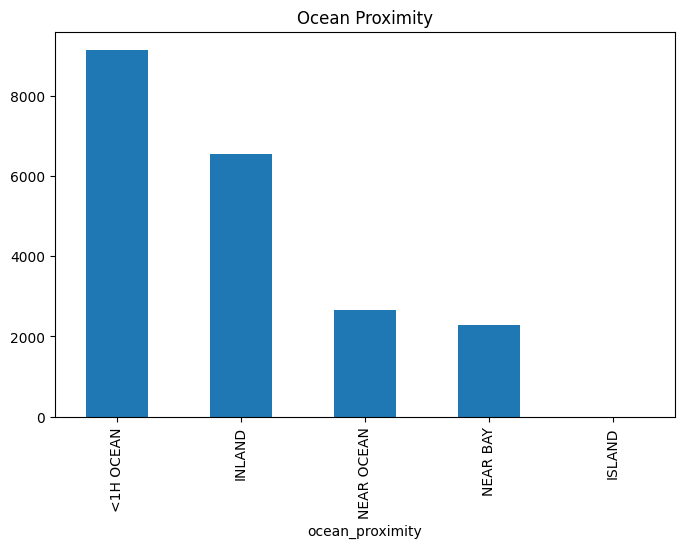

In [56]:
plt.figure(figsize=(8,5))

housing["ocean_proximity"].value_counts().plot(
    kind="bar"
)

plt.title("Ocean Proximity")
plt.show()

Income vs House Value

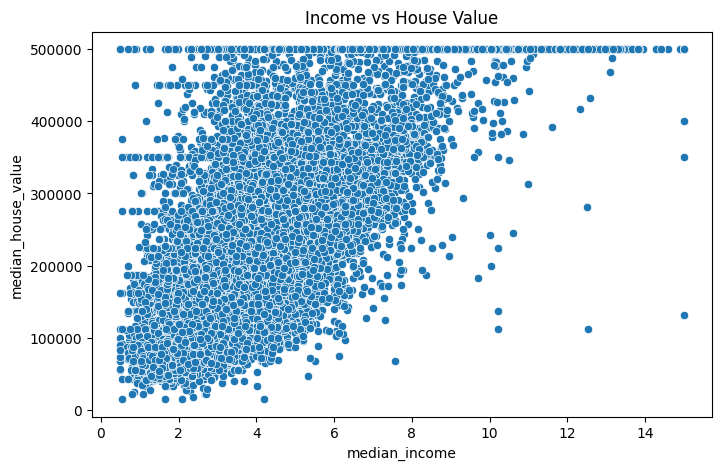

In [57]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="median_income",
    y="median_house_value",
    data=housing
)

plt.title("Income vs House Value")
plt.show()

**5. Define Features and Target**

In [58]:
X = housing.drop("median_house_value", axis=1)

y = housing["median_house_value"]

**6. Train / Validation / Test Split**

Required percentages:


* Train = 60%
* Validation = 20%
* Test = 20%


Step 1: Split Train 60% and Remaining 40%

In [59]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42
)

Step 2: Split Remaining into Validation and Test

In [60]:
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

**Verify Sizes**

In [61]:
print("Train:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

Train: (12384, 9)
Validation: (4128, 9)
Test: (4128, 9)


**7. Handle Missing Values, Encoding, Scaling**

Numerical Features

In [62]:
num_features = X.select_dtypes(include=np.number).columns

Categorical Features

In [63]:
cat_features = ["ocean_proximity"]

**Preprocessing Pipeline**

In [64]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

**8. Build Model**

Random Forest usually performs much better than Linear Regression on this dataset.

In [65]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

**9. Create Full Pipeline**

In [66]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

**10. Train Model**

In [67]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model',
                 RandomForestRegressor(max_depth=20, n_estimators=300,
                                       n_jobs=-1, random_state=42))])

**11. Validation Evaluation**

In [68]:
valid_pred = pipeline.predict(X_valid)

valid_mae = mean_absolute_error(y_valid, valid_pred)
valid_mse = mean_squared_error(y_valid, valid_pred)
valid_r2 = r2_score(y_valid, valid_pred)

print("Validation MAE:", valid_mae)
print("Validation MSE:", valid_mse)
print("Validation R² :", valid_r2)

Validation MAE: 32393.550250262615
Validation MSE: 2508874339.4013987
Validation R² : 0.8077986761948025


**12. Test Evaluation**

In [69]:
test_pred = pipeline.predict(X_test)

test_mae = mean_absolute_error(y_test, test_pred)
test_mse = mean_squared_error(y_test, test_pred)
test_r2 = r2_score(y_test, test_pred)

print("Test MAE:", test_mae)
print("Test MSE:", test_mse)
print("Test R² :", test_r2)

Test MAE: 32779.771952338124
Test MSE: 2490350669.486762
Test R² : 0.8183718246364224


**13. Train Metrics**

In [70]:
train_pred = pipeline.predict(X_train)

train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)

print("Train MAE:", train_mae)
print("Train MSE:", train_mse)

Train MAE: 12661.616747106587
Train MSE: 357414914.4339634


**14. Final Metrics Table**

In [71]:
results = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "MAE": [train_mae, test_mae],
    "MSE": [train_mse, test_mse]
})

results

,Dataset,MAE,MSE
0,Train,12661.616747,3.574149e+08
1,Test,32779.771952,2.490351e+09


**15. Actual vs Predicted Visualization**

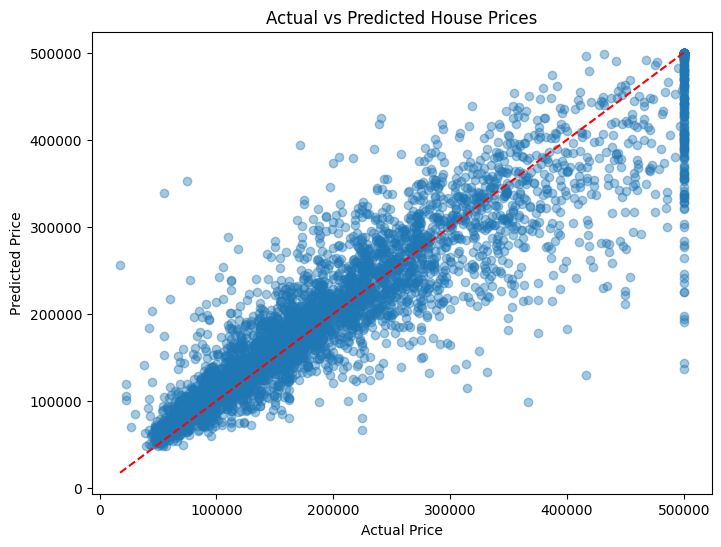

In [72]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    test_pred,
    alpha=0.4
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

**16. Error Distribution**

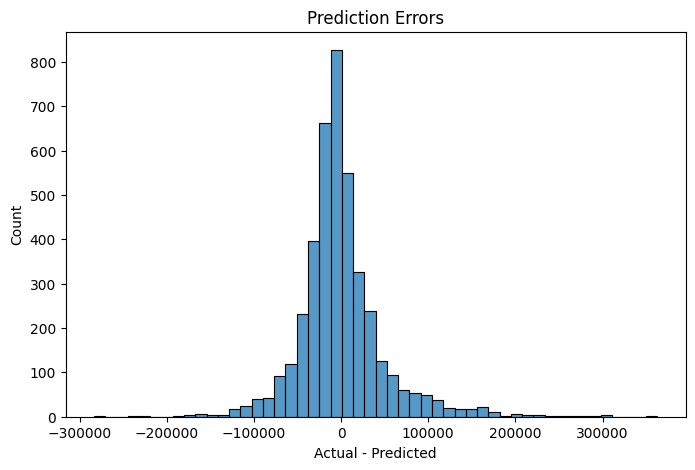

In [73]:
errors = y_test - test_pred

plt.figure(figsize=(8,5))

sns.histplot(errors, bins=50)

plt.title("Prediction Errors")
plt.xlabel("Actual - Predicted")

plt.show()

**17. Feature Importance**

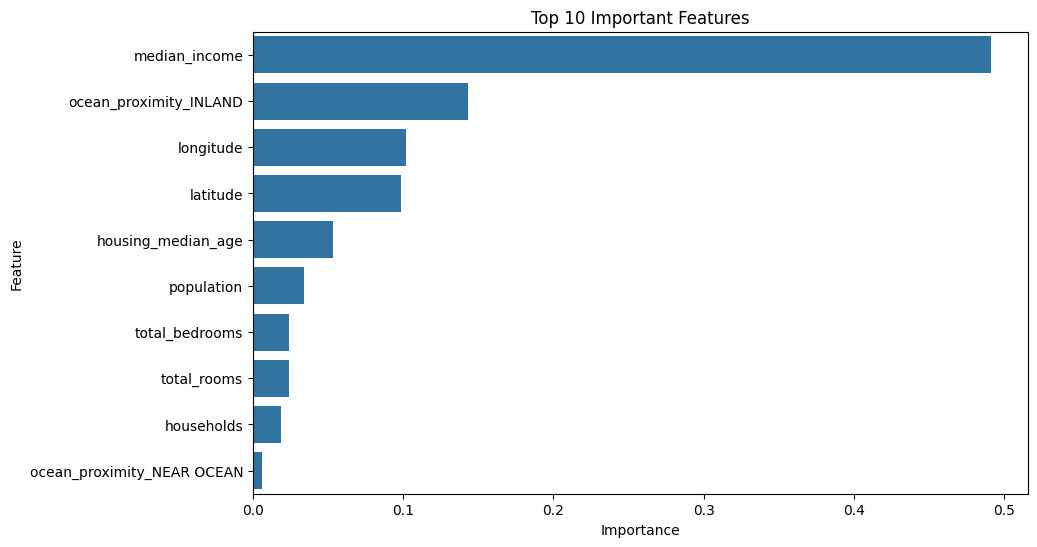

In [74]:
feature_names = (
    list(num_features)
    +
    list(
        pipeline.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .named_steps["encoder"]
        .get_feature_names_out(cat_features)
    )
)

importances = (
    pipeline.named_steps["model"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

**Problems Solved During the Process**

| Problem                               | Solution                                |
| ------------------------------------- | --------------------------------------- |
| Missing values in `total_bedrooms`    | Median imputation                       |
| Categorical feature `ocean_proximity` | One-Hot Encoding                        |
| Different feature scales              | StandardScaler                          |
| Data leakage                          | Preprocessing inside Pipeline           |
| Model evaluation                      | Separate Validation and Test sets       |
| Overfitting risk                      | Validation set and Random Forest tuning |


**Expected Conclusion**

The strongest predictor is usually median_income, followed by location features (longitude, latitude) and ocean proximity. The Random Forest model generally achieves an R² above 0.80 on this dataset, making it a solid baseline for house-price prediction.